In [ ]:
# Package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split

In [199]:
# Read CSV files
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')
df_external = pd.read_csv("external/f1_strategy_dataset_v4.csv")


In [ ]:
#Merging the external data function
def merge_external_data(df_train, df_external):
    df_train=df_train.drop(['id'],axis=1)
    # External data has extra column Normalized_TyreLife
    df_external=df_external.drop(['Normalized_TyreLife'],axis=1)
    #Setting External data to 1 for experimentation
    df_external["is_external_data"]= 1
    df_train["is_external_data"]= 0
    df_train=pd.concat([df_train, df_external], axis=0)
    #shuffling the data because we dont want it appened at the end
    df_train=df_train.sample(frac=1)
    df_train.reset_index(drop=True,inplace=True)
    return df_train

In [202]:
df_train_merged = merge_external_data(df_train, df_external)

In [203]:
df_train_merged.isnull().sum()
df_train_merged = df_train_merged.dropna(subset=['Compound']).reset_index(drop=True)

In [204]:
import pandas as pd

def balance_dataset_5050(df, target_col="PitNextLap", random_state=42):
    """
    Downsamples the majority class to match the minority class count (50/50 split),
    keeps all minority class data, and shuffles the output dataframe.
    """
    # Separate minority (pit) and majority (no-pit) classes
    value_counts = df[target_col].value_counts()
    minority_class = value_counts.idxmin()
    majority_class = value_counts.idxmax()
    
    df_minority = df[df[target_col] == minority_class]
    df_majority = df[df[target_col] == majority_class]
    
    # Downsample majority class to match minority count
    df_majority_sampled = df_majority.sample(n=len(df_minority), random_state=random_state)
    
    # Combine and shuffle
    df_balanced = (
        pd.concat([df_minority, df_majority_sampled])
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )
    
    return df_balanced



In [205]:
df_train["is_external_data"]= 0
df_test["is_external_data"]= 0

In [206]:
df_train_merged["PitNextLap"].value_counts()

PitNextLap
0.0    427273
1.0    113172
Name: count, dtype: int64

In [207]:
df_test.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
is_external_data          0
dtype: int64

In [208]:
#Check initial columns
print(df_train.columns)

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'is_external_data'],
      dtype='object')


In [209]:
df_train_merged.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,is_external_data
0,PEA,MEDIUM,Dutch Grand Prix,2025,0,10,1,9.0,17,77.373,-5.548,-21.786,0.131579,-10.0,0.0,0
1,ALO,MEDIUM,United States Grand Prix,2024,1,10,1,10.0,11,101.928,3.163,-34.550,0.131579,-4.0,0.0,1
2,D269,MEDIUM,Mexico City Grand Prix,2024,0,11,1,11.0,13,82.812,-12.947,-65.500,0.144737,-6.0,0.0,0
3,SAI,MEDIUM,Spanish Grand Prix,2024,0,34,2,29.0,5,81.325,-2.072,-40.635,0.441558,10.0,1.0,0
4,D203,HARD,Australian Grand Prix,2024,1,16,3,1.0,16,89.087,-8.725,-19.858,0.210526,1.0,0.0,0


In [210]:
df_train_merged.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'is_external_data'],
      dtype='object')

In [ ]:
#Feature Engineering
#Tyre Life
def add_tire_life_columns(df):
    max_tire_life = {
        "MEDIUM": 40,
        "HARD": 55,
        "SOFT": 30,
        "INTERMEDIATE": 25,
        "WET": 20
    }

    df["MaxTireLife"] = df["Compound"].map(max_tire_life)

    df["TireRemainingLife"] = (
        df["MaxTireLife"] - df["TyreLife"]
    ).clip(lower=0)
    df["TireAgePct"] = (
    df["TyreLife"] / df["MaxTireLife"]).clip(0, 1)
    df["TireRemainingPct"] = (df["TireRemainingLife"] / df["MaxTireLife"]).clip(0, 1)
    

    return df

# Laps
def add_laps_for_each_race(df):
    df["RaceLaps"] = (
    df["LapNumber"] / (df["RaceProgress"])
).round()
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df

# Position
def prev_position_calcute(df):
    df["Prev_Position"] = df["Position"] + df["Position_Change"]
    return df


#  LapTimeAvg_3
def get_trend_data(df):
    df["LapTimeAvg_3"] = (
        df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
    return df

## Did not use v4
def calculate_race_progress(df, is_drop=True):
    condition = (df["Race"] == "Pre-Season Testing") & (
        (df["RaceLaps"] < 31) | (df["RaceLaps"] > 78)
    )
    
    if is_drop:
        # Keep rows that do NOT match the condition
        df = df[~condition] 
    F1_RACE_LAPS = {
        "Bahrain Grand Prix": 57,
        "Saudi Arabian Grand Prix": 50,
        "Australian Grand Prix": 58,
        "Azerbaijan Grand Prix": 51,
        "Miami Grand Prix": 57,
        "Monaco Grand Prix": 78,
        "Spanish Grand Prix": 66,
        "Canadian Grand Prix": 70,
        "Austrian Grand Prix": 71,
        "British Grand Prix": 52,
        "Hungarian Grand Prix": 70,
        "Belgian Grand Prix": 44,
        "Dutch Grand Prix": 72,
        "Italian Grand Prix": 51,
        "Singapore Grand Prix": 62,
        "Japanese Grand Prix": 53,
        "Qatar Grand Prix": 57,
        "United States Grand Prix": 56,
        "Mexico City Grand Prix": 71,
        "São Paulo Grand Prix": 71,
        "Las Vegas Grand Prix": 50,
        "Abu Dhabi Grand Prix": 58,
        'Pre-Season Test': 78,
        'Pre-Season Track Session':58,
        'Chinese Grand Prix':56,
        'French Grand Prix':53,
        'Emilia Romagna Grand Prix':63,
        'Pre-Season Testing':58
        }
    mask = df["Race"].isin(F1_RACE_LAPS.keys())

    # Update only matching rows
    df.loc[mask, "RaceLaps"] = df.loc[mask, "Race"].map(F1_RACE_LAPS)
    df["ORG_RaceLaps"] = df["Race"].map(F1_RACE_LAPS)
    df["ORG_RaceProgress"] = df["LapNumber"] / df["ORG_RaceLaps"]
    df["ORG_LapsRemaining"] = df["ORG_RaceLaps"] - df["LapNumber"]

    #Based on Max Laps
    df["MAX_LAP_NUMBER"] = df.groupby(["Year", "Race"])["LapNumber"].transform("max")
    df["MAX_LAP_RaceProgress"] = df["LapNumber"] / df["MAX_LAP_NUMBER"]
    df["MAX_LAP_LapsRemaining"] = df["MAX_LAP_NUMBER"] - df["LapNumber"]
    return df

# Did not use v3
def set_normalize_tyreLife(df):
    df['Normalized_TyreLife'] = df['TyreLife'] / df.groupby(
        ['Year', 'Race', 'Driver', 'Stint']
    )['TyreLife'].transform('max')
    return df

# Did not use v3
def set_normalize_tyreLife_wo_driver(df):
    df['Normalized_TyreLife'] = df['TyreLife'] / df.groupby(
        ['Year', 'Race', 'Stint','Compound']
    )['TyreLife'].transform('max')
    return df

def add_group_factors(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str],
    value_col: str = "TyreLife",
    suffix: str = ""
) -> pd.DataFrame:
    """
    Computes group aggregations on df_train_merged, converts metrics into dictionary 
    factors using multi-column tuple keys, and maps them to df.
    """
    df = df.copy()

    # 1. Compute group statistics
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Stint_Count="count",
            Stint_Tyre_Mean_Life="mean",
            Stint_Tyre_Median_Life="median",
            Stint_Tyre_Min_Life="min",
            Stint_Tyre_Max_Life="max",
            Stint_Tyre_Std_Dev="std",
        )
        .reset_index()
    )

    stat_cols = ["Stint_Count", "Stint_Tyre_Mean_Life", "Stint_Tyre_Median_Life", "Stint_Tyre_Min_Life", "Stint_Tyre_Max_Life", "Stint_Tyre_Std_Dev"]

    # 2. Build tuple keys for multi-column matching
    if len(group_cols) == 1:
        keys = df[group_cols[0]]
    else:
        keys = list(zip(*[df[col] for col in group_cols]))

    # 3. Create dictionary factor for each stat and map to main DF
    for col in stat_cols:
        factor_dict = stats_all.set_index(group_cols)[col].to_dict()
        
        target_col_name = f"{col}{suffix}"
        if len(group_cols) == 1:
            df[target_col_name] = df[group_cols[0]].map(factor_dict)
        else:
            df[target_col_name] = [factor_dict.get(k) for k in keys]

    return df

def feature_engineering_v6(df,df_train_merged):
    # 1. Compute group statistics
    group_columns = ["Stint", "Compound", "Year"]

    # Map all statistical factors from df_external into df
    df = add_group_factors(
        df=df,
        df_train_merged=df_train_merged,
        group_cols=group_columns,
        value_col="TyreLife"
    )
    return df




# did not use v7
def add_lap_group_factors(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str] = ["Year", "Race","Stint"],
    value_col: str = "LapNumber",
    suffix: str = "",
) -> pd.DataFrame:
    """Computes LapNumber aggregations on df_train_merged grouped by Year and Race

    and maps them back onto df using Pandas merge.
    """
    df = df.copy()

    # 1. Compute group statistics for LapNumber
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Race_Lap_Count="count",
            Race_Lap_Mean="mean",
            Race_Lap_Median="median",
            Race_Lap_Min="min",
            Race_Lap_Max="max",
            Race_Lap_Std_Dev="std",
        )
        .reset_index()
    )

    # 2. Add custom suffix to generated metric columns if provided
    if suffix:
        rename_dict = {
            col: f"{col}{suffix}"
            for col in stats_all.columns
            if col not in group_cols
        }
        stats_all = stats_all.rename(columns=rename_dict)

    # 3. Join aggregated features back to the target dataframe
    df = df.merge(stats_all, on=group_cols, how="left")

    return df


def feature_engineering_lap_numbers_v7(df: pd.DataFrame, df_train_merged: pd.DataFrame) -> pd.DataFrame:
    # Group specifically by Year and Race for LapNumber features
    group_columns = ["Year", "Race","Stint","Compound"]

    df = add_lap_group_factors(
        df=df,
        df_train_merged=df_train_merged,
        group_cols=group_columns,
        value_col="LapNumber",
    )

    return df

def set_fe_v1(df):
    
    df = add_tire_life_columns(df)
    df = add_laps_for_each_race(df)
    df= prev_position_calcute(df)
    df = get_trend_data(df)
    return df


def feature_engineering_v8(df):
    df = df.copy()

    group_cols = ['Year', 'Race', 'Driver','Stint']

    df['PitCount'] = (
        df.groupby(group_cols)['PitStop']
          .cumsum()
    )

    #Too many null values
    # df['PreviousPitLap'] = (
    #     df['LapNumber']
    #     .where(df['PitStop'] == 1)
    #     .groupby([df[c] for c in group_cols])
    #     .ffill()
    # )

    # df['LapsSincePit'] = (
    #     df['LapNumber'] - df['PreviousPitLap']
    # )

    # # -----------------------------
    # # Previous compound
    # # -----------------------------
    # df['PreviousCompound'] = (
    #     df.groupby(group_cols)['Compound']
    #       .shift(1)
    # )

    # -----------------------------
    # Rolling lap-time features
    # -----------------------------
    df['RollingLapTime_3'] = (
        df.groupby(group_cols)['LapTime (s)']
          .transform(
              lambda x: x.rolling(3, min_periods=1).mean()
          )
    )

    if 'LapTime_Delta' in df.columns:
        df['RollingLapTimeDelta_3'] = (
            df.groupby(group_cols)['LapTime_Delta']
              .transform(
                  lambda x: x.rolling(3, min_periods=1).mean()
              )
        )

        # Recent degradation Too many null values
        # df['RecentDegradation'] = (
        #     df.groupby(group_cols)['LapTime_Delta']
        #       .transform(
        #           lambda x: x.rolling(5, min_periods=2).mean()
        #       )
        # )

        # # Degradation rate
        # df['DegradationRate'] = (
        #     df.groupby(group_cols)['LapTime_Delta']
        #       .transform(
        #           lambda x: x.diff()
        #       )
        # )

    # -----------------------------
    # Position trend
    # -----------------------------
    df['Position_Change_3Lap'] = (
        df.groupby(group_cols)['Position_Change']
          .transform(
              lambda x: x.rolling(3, min_periods=1).sum()
          )
        if 'Position_Change' in df.columns
        else 0
    )

    # -----------------------------
    # Tyre features
    # -----------------------------
    COMPOUND_HARDNESS = {
        'SOFT': 1,
        'MEDIUM': 2,
        'HARD': 3,
        'INTERMEDIATE': 4,
        'WET': 5
    }


    df['Compound_Hardness'] = (
        df['Compound'].map(COMPOUND_HARDNESS)
    )

    # -----------------------------
    # Remove temporary / invalid values
    # -----------------------------
    df.replace([float('inf'), -float('inf')], 0, inplace=True)

    return df



def add_lap_time_delta_group_factors(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str] | None = None,
    value_col: str = "LapTime_Delta",
    suffix: str = "",
) -> pd.DataFrame:
    """Computes group aggregations for LapTime_Delta on df_train_merged, converts

    metrics into dictionary factors using multi-column tuple keys, and maps them
    to df.

    Parameters:
    -----------
    df : pd.DataFrame
        Target DataFrame to map engineered feature columns onto.
    df_train_merged : pd.DataFrame
        Source DataFrame used to calculate statistical aggregates.
    group_cols : list[str], optional
        Columns to group by. Defaults to ["Race", "Year", "PitNextLap"].
    value_col : str, default 'LapTime_Delta'
        Metric column to aggregate.
    suffix : str, default ''
        Suffix added to engineered column names (e.g., '_PitLapGroup').

    Returns:
    --------
    pd.DataFrame
        Copy of target DataFrame containing new aggregated factor columns.
    """
    if group_cols is None:
        group_cols = ["Race", "Year", "PitNextLap"]

    df = df.copy()

    # 1. Compute group statistics
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Lap_Count="count",
            LapTime_Delta_Mean="mean",
            LapTime_Delta_Median="median",
            LapTime_Delta_Min="min",
            LapTime_Delta_Max="max",
            LapTime_Delta_Std_Dev="std",
        )
        .reset_index()
    )

    stat_cols = [
        "Lap_Count",
        "LapTime_Delta_Mean",
        "LapTime_Delta_Median",
        "LapTime_Delta_Min",
        "LapTime_Delta_Max",
        "LapTime_Delta_Std_Dev",
    ]

    # 2. Build tuple keys for multi-column matching
    if len(group_cols) == 1:
        keys = df[group_cols[0]]
    else:
        keys = list(zip(*[df[col] for col in group_cols]))

    # 3. Create dictionary factor for each stat and map to main DF
    for col in stat_cols:
        factor_dict = stats_all.set_index(group_cols)[col].to_dict()

        target_col_name = f"{col}{suffix}"
        if len(group_cols) == 1:
            df[target_col_name] = df[group_cols[0]].map(factor_dict)
        else:
            df[target_col_name] = [factor_dict.get(k) for k in keys]

    return df


def add_lap_time_delta_group_factors_WO_DRIVER(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str] | None = None,
    value_col: str = "LapTime_Delta",
    suffix: str = "",
) -> pd.DataFrame:
    """Computes group aggregations for LapTime_Delta on df_train_merged, converts

    metrics into dictionary factors using multi-column tuple keys, and maps them
    to df.

    Parameters:
    -----------
    df : pd.DataFrame
        Target DataFrame to map engineered feature columns onto.
    df_train_merged : pd.DataFrame
        Source DataFrame used to calculate statistical aggregates.
    group_cols : list[str], optional
        Columns to group by. Defaults to ["Race", "Year", "PitNextLap"].
    value_col : str, default 'LapTime_Delta'
        Metric column to aggregate.
    suffix : str, default ''
        Suffix added to engineered column names (e.g., '_PitLapGroup').

    Returns:
    --------
    pd.DataFrame
        Copy of target DataFrame containing new aggregated factor columns.
    """
    if group_cols is None:
        group_cols = ["Race", "Year", "PitNextLap"]

    df = df.copy()

    # 1. Compute group statistics
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Lap_Count="count",
            LapTime_Delta_Mean="mean",
            LapTime_Delta_Median="median",
            LapTime_Delta_Min="min",
            LapTime_Delta_Max="max",
            LapTime_Delta_Std_Dev="std",
        )
        .reset_index()
    )

    stat_cols = [
        "Lap_Count",
        "LapTime_Delta_Mean",
        "LapTime_Delta_Median",
        "LapTime_Delta_Min",
        "LapTime_Delta_Max",
        "LapTime_Delta_Std_Dev",
    ]

    # 2. Build tuple keys for multi-column matching
    if len(group_cols) == 1:
        keys = df[group_cols[0]]
    else:
        keys = list(zip(*[df[col] for col in group_cols]))

    # 3. Create dictionary factor for each stat and map to main DF
    for col in stat_cols:
        factor_dict = stats_all.set_index(group_cols)[col].to_dict()

        target_col_name = f"{col}{suffix}"
        if len(group_cols) == 1:
            df[target_col_name] = df[group_cols[0]].map(factor_dict)
        else:
            df[target_col_name] = [factor_dict.get(k) for k in keys]

    return df

def feature_engineering_v9(df,df_train_merged):
    # 1. Compute group statistics
    group_columns = ["Race", "Year","Compound","Stint"]

    # Map all statistical factors from df_external into df
    df = add_lap_time_delta_group_factors(
        df=df,
        df_train_merged=df_train_merged,
        group_cols=group_columns,
        value_col="LapTime_Delta"
    )

    group_columns = ["Race", "Year"]
    df = add_lap_time_delta_group_factors(
            df=df,
            df_train_merged=df_train_merged,
            group_cols=group_columns,
            value_col="LapTime_Delta",
            suffix="WO_DRIVER"
        )
    
    return df

In [212]:
# df_external_fe =set_fe(df_external.copy())
df_train_fe =set_fe_v1(df_train.copy())
df_train_merged_fe =set_fe_v1(df_train_merged.copy())
df_test_fe =set_fe_v1(df_test.copy())

In [213]:
df_train_fe =feature_engineering_v6(df_train_fe,df_train_merged_fe)
df_train_merged_fe =feature_engineering_v6(df_train_merged_fe,df_train_merged_fe)
df_test_fe =feature_engineering_v6(df_test_fe,df_train_merged_fe)


In [ ]:
# df_train_fe =feature_engineering_v9(df_train_fe,df_train_merged_fe)
# df_train_merged_fe =feature_engineering_v9(df_train_merged_fe,df_train_merged_fe)
# df_test_fe =feature_engineering_v9(df_test_fe,df_train_merged_fe)

In [214]:
df_train_merged_fe.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'is_external_data', 'MaxTireLife', 'TireRemainingLife',
       'TireAgePct', 'TireRemainingPct', 'RaceLaps', 'LapsRemaining',
       'Prev_Position', 'LapTimeAvg_3', 'Stint_Count', 'Stint_Tyre_Mean_Life',
       'Stint_Tyre_Median_Life', 'Stint_Tyre_Min_Life', 'Stint_Tyre_Max_Life',
       'Stint_Tyre_Std_Dev'],
      dtype='object')

In [108]:
df_train_merged_fe[[ 'Lap_Count', 'LapTime_Delta_Mean',
       'LapTime_Delta_Median', 'LapTime_Delta_Min', 'LapTime_Delta_Max',
       'LapTime_Delta_Std_Dev', 'Lap_CountWO_DRIVER',
       'LapTime_Delta_MeanWO_DRIVER', 'LapTime_Delta_MedianWO_DRIVER',
       'LapTime_Delta_MinWO_DRIVER', 'LapTime_Delta_MaxWO_DRIVER',
       'LapTime_Delta_Std_DevWO_DRIVER']].head()

,Lap_Count,LapTime_Delta_Mean,LapTime_Delta_Median,LapTime_Delta_Min,LapTime_Delta_Max,LapTime_Delta_Std_Dev,Lap_CountWO_DRIVER,LapTime_Delta_MeanWO_DRIVER,LapTime_Delta_MedianWO_DRIVER,LapTime_Delta_MinWO_DRIVER,LapTime_Delta_MaxWO_DRIVER,LapTime_Delta_Std_DevWO_DRIVER
0,3,-1.320000,0.000,-9.676,5.716,7.780438,56,-4.335089,-5.5385,-34.689,21.82,9.892631
1,3,-1.320000,0.000,-9.676,5.716,7.780438,56,-4.335089,-5.5385,-34.689,21.82,9.892631
2,3,-1.320000,0.000,-9.676,5.716,7.780438,56,-4.335089,-5.5385,-34.689,21.82,9.892631
3,6,-0.483667,-0.172,-8.767,7.710,6.515298,56,-4.335089,-5.5385,-34.689,21.82,9.892631
4,6,-0.483667,-0.172,-8.767,7.710,6.515298,56,-4.335089,-5.5385,-34.689,21.82,9.892631


In [21]:
df_train_merged_fe["Race"].unique()

array(['Abu Dhabi Grand Prix', 'Australian Grand Prix',
       'Austrian Grand Prix', 'Azerbaijan Grand Prix',
       'Bahrain Grand Prix', 'Belgian Grand Prix', 'British Grand Prix',
       'Canadian Grand Prix', 'Chinese Grand Prix', 'Dutch Grand Prix',
       'Emilia Romagna Grand Prix', 'French Grand Prix',
       'Hungarian Grand Prix', 'Italian Grand Prix',
       'Japanese Grand Prix', 'Las Vegas Grand Prix',
       'Mexico City Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix',
       'Pre-Season Testing', 'Qatar Grand Prix',
       'Saudi Arabian Grand Prix', 'Singapore Grand Prix',
       'Spanish Grand Prix', 'São Paulo Grand Prix',
       'United States Grand Prix', 'Pre-Season Test',
       'Pre-Season Track Session'], dtype=object)

In [93]:
df_train_fe['is_external_data']=0
df_test_fe['is_external_data']=0

In [23]:
# df_train_fe =run_all_f1_feature_engineering(df_train_fe)
# df_train_merged_fe =run_all_f1_feature_engineering(df_train_merged_fe)
# df_test_fe =run_all_f1_feature_engineering(df_test_fe)

In [24]:

# df_train_fe =add_50_additional_f1_features(df_train_fe)
# df_train_merged_fe =add_50_additional_f1_features(df_train_merged_fe)
# df_test_fe =add_50_additional_f1_features(df_test_fe)

In [29]:
# df_train_fe =feature_engineering_lap_numbers_v7(df_train_fe,df_train_merged_fe)
# df_train_merged_fe =feature_engineering_lap_numbers_v7(df_train_merged_fe,df_train_merged_fe)
# df_test_fe =feature_engineering_lap_numbers_v7(df_test_fe,df_train_merged_fe)


In [30]:

# df_train_fe =feature_engineering_v8(df_train_fe)
# df_train_merged_fe =feature_engineering_v8(df_train_merged_fe)
# df_test_fe =feature_engineering_v8(df_test_fe)


In [ ]:
# Example Usage:
# df_train_balanced = balance_dataset_5050(df_train_merged, target_col="PitNextLap")
# print(df_train_balanced["PitNextLap"].value_counts())

PitNextLap
0.0    113172
1.0    113172
Name: count, dtype: int64


In [ ]:
# dropping ID not required
df_train =df_train.drop("id",axis=1)
# df_test =df_test.drop("id",axis=1)

In [ ]:
# dropping ID not required
df_train_fe =df_train_fe.drop("id",axis=1)
# df_test_fe =df_test_fe.drop("id",axis=1)

In [171]:
df_train_merged_fe= df_train_merged_fe.drop("is_external_data",axis=1)

In [174]:
print(df_train_merged_fe.isnull().sum())

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
MaxTireLife               0
TireRemainingLife         0
TireAgePct                0
TireRemainingPct          0
RaceLaps                  0
LapsRemaining             0
Prev_Position             0
LapTimeAvg_3              0
Stint_Count               0
Stint_Tyre_Mean_Life      0
Stint_Tyre_Median_Life    0
Stint_Tyre_Min_Life       0
Stint_Tyre_Max_Life       0
Stint_Tyre_Std_Dev        0
dtype: int64


In [175]:
df_test_fe.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
is_external_data          0
MaxTireLife               0
TireRemainingLife         0
TireAgePct                0
TireRemainingPct          0
RaceLaps                  0
LapsRemaining             0
Prev_Position             0
LapTimeAvg_3              0
Stint_Count               0
Stint_Tyre_Mean_Life      0
Stint_Tyre_Median_Life    0
Stint_Tyre_Min_Life       0
Stint_Tyre_Max_Life       0
Stint_Tyre_Std_Dev        0
dtype: int64

In [173]:
df_train_merged_fe['Stint_Tyre_Std_Dev'] = df_train_merged_fe['Stint_Tyre_Std_Dev'].fillna(0)
# df_train_merged_fe['LapTime_Delta_Std_Dev'] = df_train_merged_fe['LapTime_Delta_Std_Dev'].fillna(0)
cols = [
    'Stint_Count',
    'Stint_Tyre_Mean_Life',
    'Stint_Tyre_Median_Life',
    'Stint_Tyre_Min_Life',
    'Stint_Tyre_Max_Life',
    'Stint_Tyre_Std_Dev'
]

df_test_fe[cols] = df_test_fe[cols].fillna(0)

# cols = [
#     'Lap_Count',
#     'LapTime_Delta_Mean',
#     'LapTime_Delta_Median',
#     'LapTime_Delta_Min',
#     'LapTime_Delta_Max',
#     'LapTime_Delta_Std_Dev'
# ]

# df_test_fe[cols] = df_test_fe[cols].fillna(0)

In [ ]:
# # Example Usage:
# df_train_merged_fe = balance_dataset_5050(df_train_merged_fe, target_col="PitNextLap")
# print(df_train_balanced["PitNextLap"].value_counts())

PitNextLap
0.0    113172
1.0    113172
Name: count, dtype: int64


In [176]:
df_train_merged_fe.nunique().sort_values(ascending=False)

LapTimeAvg_3              192067
Cumulative_Degradation    164086
LapTime_Delta              73340
LapTime (s)                45108
RaceProgress                1947
Driver                       887
TireRemainingPct             130
TireAgePct                   130
RaceLaps                     123
LapsRemaining                117
Stint_Tyre_Mean_Life         117
Stint_Tyre_Std_Dev           113
Stint_Count                  101
TyreLife                      79
LapNumber                     78
Stint_Tyre_Max_Life           58
TireRemainingLife             55
Prev_Position                 50
Position_Change               37
Race                          28
Stint_Tyre_Median_Life        27
Position                      20
Stint_Tyre_Min_Life           18
Stint                          8
Compound                       5
MaxTireLife                    5
Year                           4
PitStop                        2
PitNextLap                     2
dtype: int64

In [177]:
df_train_merged_fe.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,BAD,SOFT,Spanish Grand Prix,2025,0,13,1,16.0,8,82.979,...,76.0,63.0,5.0,82.979,5268,10.339408,9.0,1.0,45.0,7.119890
1,MAL,SOFT,Pre-Season Testing,2023,0,50,2,19.0,12,91.894,...,52.0,2.0,12.0,91.894,2402,14.061615,14.0,1.0,42.0,6.746708
2,D010,MEDIUM,Chinese Grand Prix,2025,0,9,1,9.0,8,99.118,...,77.0,68.0,16.0,99.118,42637,11.793982,11.0,1.0,55.0,8.312222
3,MCN,MEDIUM,Qatar Grand Prix,2023,0,8,1,13.0,7,90.847,...,57.0,49.0,8.0,90.847,50575,11.285536,10.0,1.0,64.0,7.859122
4,HAM,MEDIUM,Japanese Grand Prix,2025,1,41,2,11.0,7,91.569,...,78.0,37.0,7.0,91.569,10340,14.806963,14.0,1.0,75.0,8.957588


In [118]:
# Dataset split but used entire dataset as we were loosing accuracy


# Step 1: Split into Train (80%) and Temp (20%)
df_train_split, df_temp_split = train_test_split(
    df_train_merged_fe, 
    test_size=0.20, 
    random_state=42
)

# Step 2: Split Temp evenly into Validation (10%) and Test (10%)
df_val_split, df_test_split = train_test_split(
    df_temp_split, 
    test_size=0.50, 
    random_state=42
)

# Verify the sizes
print(f"Train: {len(df_train_split)} ({len(df_train_split)/len(df_train_merged_fe):.0%})")
print(f"Validation: {len(df_val_split)} ({len(df_val_split)/len(df_train_merged_fe):.0%})")
print(f"Test: {len(df_test_split)} ({len(df_test_split)/len(df_train_merged_fe):.0%})")


Train: 432356 (80%)
Validation: 54044 (10%)
Test: 54045 (10%)


In [119]:
df_train_merged_fe.isnull().sum()

Driver                            0
Compound                          0
Race                              0
Year                              0
PitStop                           0
LapNumber                         0
Stint                             0
TyreLife                          0
Position                          0
LapTime (s)                       0
LapTime_Delta                     0
Cumulative_Degradation            0
RaceProgress                      0
Position_Change                   0
PitNextLap                        0
MaxTireLife                       0
TireRemainingLife                 0
TireAgePct                        0
TireRemainingPct                  0
RaceLaps                          0
LapsRemaining                     0
Prev_Position                     0
LapTimeAvg_3                      0
Stint_Count                       0
Stint_Tyre_Mean_Life              0
Stint_Tyre_Median_Life            0
Stint_Tyre_Min_Life               0
Stint_Tyre_Max_Life         

In [178]:

TARGET = 'PitNextLap'

print(df_train_merged_fe[TARGET].value_counts())

PitNextLap
0.0    427273
1.0    113172
Name: count, dtype: int64


In [121]:
df_train_merged_fe.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,LapTime_Delta_Median,LapTime_Delta_Min,LapTime_Delta_Max,LapTime_Delta_Std_Dev,Lap_CountWO_DRIVER,LapTime_Delta_MeanWO_DRIVER,LapTime_Delta_MedianWO_DRIVER,LapTime_Delta_MinWO_DRIVER,LapTime_Delta_MaxWO_DRIVER,LapTime_Delta_Std_DevWO_DRIVER
0,ALB,MEDIUM,Abu Dhabi Grand Prix,2022,0,1,1,1.0,19,116.433,...,0.000,-9.676,5.716,7.780438,56,-4.335089,-5.5385,-34.689,21.82,9.892631
1,ALB,HARD,Abu Dhabi Grand Prix,2022,1,18,2,7.0,16,90.053,...,0.000,-9.676,5.716,7.780438,56,-4.335089,-5.5385,-34.689,21.82,9.892631
2,ALB,MEDIUM,Abu Dhabi Grand Prix,2022,1,61,3,27.0,15,88.064,...,0.000,-9.676,5.716,7.780438,56,-4.335089,-5.5385,-34.689,21.82,9.892631
3,ALO,MEDIUM,Abu Dhabi Grand Prix,2022,0,1,1,1.0,10,89.929,...,-0.172,-8.767,7.710,6.515298,56,-4.335089,-5.5385,-34.689,21.82,9.892631
4,ALO,MEDIUM,Abu Dhabi Grand Prix,2022,0,8,1,8.0,3,90.673,...,-0.172,-8.767,7.710,6.515298,56,-4.335089,-5.5385,-34.689,21.82,9.892631


In [179]:
# As per model and data analysis Removing driver gives more accuracy
df_train_merged_wo_driver = df_train_merged_fe.drop("Driver", axis=1)
df_train_wo_driver = df_train_fe.drop("Driver", axis=1)
df_test_wo_driver = df_test_fe.drop("Driver", axis=1)

In [180]:
#Adding patch for pandas error while training autologon
import warnings
warnings.filterwarnings(
    "ignore", category=FutureWarning, message=".*downcast.*"
)
_orig_fillna = pd.DataFrame.fillna
def _patched_fillna(self, *args, **kwargs):
    kwargs.pop("downcast", None)
    return _orig_fillna(self, *args, **kwargs)

In [181]:
# Earlier testing used 3 models (Output within 30 mins 5 models take 4 hours with num_stack=1)
models = {
    # --- Existing Gradient Boosted Trees ---
    "GBM": [
        {},  # Standard LightGBM
        {"extra_trees": True, "ag_args": {"name_suffix": "Large"}},  # ExtraTrees LightGBM
    ],
    "XGB": {},  # XGBoost
    "CAT": {},  # CatBoost
}


# models = {
#     # --- Existing Gradient Boosted Trees ---
#     "GBM": [
#         {},  # Standard LightGBM
#         {"extra_trees": True, "ag_args": {"name_suffix": "Large"}},  # ExtraTrees LightGBM
#     ],
#     "XGB": {},  # XGBoost
#     "CAT": {},  # CatBoost

#     # --- TOP ADDITION 1: PyTorch Neural Network ---
#     "NN_TORCH": {},  # Generates NeuralNetTorch_BAG_L1

#     # --- TOP ADDITION 2: Extra Trees (Gini & Entropy) ---
#     "XT": [
#         {"criterion": "gini", "ag_args": {"name_suffix": "Gini"}},
#         {"criterion": "entropy", "ag_args": {"name_suffix": "Entr"}},
#     ],
# }

In [182]:
df_train_merged_fe.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'MaxTireLife', 'TireRemainingLife', 'TireAgePct',
       'TireRemainingPct', 'RaceLaps', 'LapsRemaining', 'Prev_Position',
       'LapTimeAvg_3', 'Stint_Count', 'Stint_Tyre_Mean_Life',
       'Stint_Tyre_Median_Life', 'Stint_Tyre_Min_Life', 'Stint_Tyre_Max_Life',
       'Stint_Tyre_Std_Dev'],
      dtype='object')

In [183]:
# predictor = TabularPredictor(
#     label=TARGET, 
#     eval_metric='roc_auc', 
#     path='ag_models20'
# ).fit(
#     train_data=df_train_merged_fe,
#     ag_args_fit={"num_gpus": 1},
#     time_limit=3600*3,
#     presets='best_quality',
#     verbosity=3,
#     num_stack_levels=1,
#     hyperparameters=models,
    
#     # Place it here inside .fit()
#     hyperparameter_tune_kwargs={
#         'num_trials': 3,
#         'scheduler': 'local',
#         'searcher': 'auto'
#     }
# )

predictor = TabularPredictor(label=TARGET,eval_metric='roc_auc', path='ag_models32').fit(
    train_data=df_train_merged_wo_driver,
    ag_args_fit={"num_gpus": 1},
    time_limit=3600*3,
    presets='best_quality',
    verbosity=3,
    num_stack_levels=0,
    hyperparameters=models,
)

Verbosity: 3 (Detailed Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.8.0+cu129
CUDA Version:       12.9
GPU Memory:         GPU 0: 15.93/15.93 GB
Total GPU Memory:   Free: 15.93 GB, Allocated: 0.00 GB, Total: 15.93 GB
GPU Count:          1
Memory Avail:       3.68 GB / 15.06 GB (24.4%)
Disk Space Avail:   614.33 GB / 930.47 GB (66.0%)
Presets specified: ['best_quality']
============ fit kwarg info ============
User Specified kwargs:
{'ag_args_fit': {'num_gpus': 1},
 'auto_stack': True,
 'num_stack_levels': 0,
 'verbosity': 3}
Full kwargs:
{'_experimental_dynamic_hyperparameters': False,
 '_feature_generator_kwargs': None,
 '_save_bag_folds': None,
 'adapt_num_bag_folds_to_n_classes': False,
 'ag_args': None,
 'ag_args_ensemble': None,
 'ag_args_fit': {'num_gpus': 1},
 'auto_stack': True,
 '

[50]	valid_set's binary_logloss: 0.281995
[100]	valid_set's binary_logloss: 0.256574
[150]	valid_set's binary_logloss: 0.246683
[200]	valid_set's binary_logloss: 0.241559
[250]	valid_set's binary_logloss: 0.238082
[300]	valid_set's binary_logloss: 0.235329
[350]	valid_set's binary_logloss: 0.232822
[400]	valid_set's binary_logloss: 0.230878
[450]	valid_set's binary_logloss: 0.229176
[500]	valid_set's binary_logloss: 0.227564
[550]	valid_set's binary_logloss: 0.226283
[600]	valid_set's binary_logloss: 0.225141
[650]	valid_set's binary_logloss: 0.224229
[700]	valid_set's binary_logloss: 0.223401
[750]	valid_set's binary_logloss: 0.222479
[800]	valid_set's binary_logloss: 0.221782
[850]	valid_set's binary_logloss: 0.221174
[900]	valid_set's binary_logloss: 0.22061
[950]	valid_set's binary_logloss: 0.219955
[1000]	valid_set's binary_logloss: 0.219496
[1050]	valid_set's binary_logloss: 0.219047
[1100]	valid_set's binary_logloss: 0.218553
[1150]	valid_set's binary_logloss: 0.218012
[1200]	va

	Fit constraints were validated upstream on the full training data, skipping...
	Fitting 10000 rounds... Hyperparameters: {'learning_rate': 0.05, 'seed': 0, 'device': 'gpu'}


[50]	valid_set's binary_logloss: 0.282615
[100]	valid_set's binary_logloss: 0.257513
[150]	valid_set's binary_logloss: 0.247424
[200]	valid_set's binary_logloss: 0.242369
[250]	valid_set's binary_logloss: 0.238799
[300]	valid_set's binary_logloss: 0.236247
[350]	valid_set's binary_logloss: 0.233739
[400]	valid_set's binary_logloss: 0.231704
[450]	valid_set's binary_logloss: 0.230212
[500]	valid_set's binary_logloss: 0.228748
[550]	valid_set's binary_logloss: 0.227575
[600]	valid_set's binary_logloss: 0.22649
[650]	valid_set's binary_logloss: 0.225328
[700]	valid_set's binary_logloss: 0.224507
[750]	valid_set's binary_logloss: 0.223777
[800]	valid_set's binary_logloss: 0.22315
[850]	valid_set's binary_logloss: 0.222513
[900]	valid_set's binary_logloss: 0.221932
[950]	valid_set's binary_logloss: 0.221359
[1000]	valid_set's binary_logloss: 0.220991
[1050]	valid_set's binary_logloss: 0.220432
[1100]	valid_set's binary_logloss: 0.219845
[1150]	valid_set's binary_logloss: 0.219331
[1200]	val

	Fit constraints were validated upstream on the full training data, skipping...
	Fitting 10000 rounds... Hyperparameters: {'learning_rate': 0.05, 'seed': 0, 'device': 'gpu'}


...

	Fit constraints were validated upstream on the full training data, skipping...


[0]	validation_0-logloss:0.47622
[50]	validation_0-logloss:0.26281
[100]	validation_0-logloss:0.24590
[150]	validation_0-logloss:0.23813
[200]	validation_0-logloss:0.23232
[250]	validation_0-logloss:0.22820
[300]	validation_0-logloss:0.22516
[350]	validation_0-logloss:0.22290
[400]	validation_0-logloss:0.22106
[450]	validation_0-logloss:0.21920
[500]	validation_0-logloss:0.21773
[550]	validation_0-logloss:0.21651
[600]	validation_0-logloss:0.21570
[650]	validation_0-logloss:0.21490
[700]	validation_0-logloss:0.21426
[750]	validation_0-logloss:0.21379
[800]	validation_0-logloss:0.21328
[850]	validation_0-logloss:0.21285
[900]	validation_0-logloss:0.21256
[950]	validation_0-logloss:0.21213
[1000]	validation_0-logloss:0.21175
[1050]	validation_0-logloss:0.21138
[1100]	validation_0-logloss:0.21103
[1150]	validation_0-logloss:0.21078
[1200]	validation_0-logloss:0.21066
[1250]	validation_0-logloss:0.21050
[1300]	validation_0-logloss:0.21033
[1350]	validation_0-logloss:0.21021
[1400]	validati

	Fit constraints were validated upstream on the full training data, skipping...


[0]	validation_0-logloss:0.47635
[50]	validation_0-logloss:0.26487
[100]	validation_0-logloss:0.24879
[150]	validation_0-logloss:0.24058
[200]	validation_0-logloss:0.23571
[250]	validation_0-logloss:0.23189
[300]	validation_0-logloss:0.22885
[350]	validation_0-logloss:0.22673
[400]	validation_0-logloss:0.22446
[450]	validation_0-logloss:0.22268
[500]	validation_0-logloss:0.22121
[550]	validation_0-logloss:0.22012
[600]	validation_0-logloss:0.21902
[650]	validation_0-logloss:0.21835
[700]	validation_0-logloss:0.21768
[750]	validation_0-logloss:0.21731
[800]	validation_0-logloss:0.21690
[850]	validation_0-logloss:0.21650
[900]	validation_0-logloss:0.21614
[950]	validation_0-logloss:0.21578
[1000]	validation_0-logloss:0.21537
[1050]	validation_0-logloss:0.21494
[1100]	validation_0-logloss:0.21460
[1150]	validation_0-logloss:0.21439
[1200]	validation_0-logloss:0.21423
[1250]	validation_0-logloss:0.21407
[1300]	validation_0-logloss:0.21382
[1350]	validation_0-logloss:0.21366
[1400]	validati

Saving c:\Darshak\Projects\Hackathon\ag_models32\models\XGBoost_BAG_L1\utils\oof.pkl
Saving c:\Darshak\Projects\Hackathon\ag_models32\models\XGBoost_BAG_L1\model.pkl
	0.9576	 = Validation score   (roc_auc)
	299.73s	 = Training   runtime
	3.02s	 = Validation runtime
	22358.5	 = Inference  throughput (rows/s | 67556 batch size)
Saving c:\Darshak\Projects\Hackathon\ag_models32\models\trainer.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\utils\oof.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBMLarge_BAG_L1\utils\oof.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\CatBoost_BAG_L1\utils\oof.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\XGBoost_BAG_L1\utils\oof.pkl
Model configs that will be trained (in order):
	WeightedEnsemble_L2: 	{'ag_args': {'problem_types': ['binary', 'multiclass', 'regression', 'quantile', 'softclass'], 'valid_base': False, 'name_bag_suffix': '', 'model_type': <class 'autogluon.core.mo

In [184]:
# predictor = TabularPredictor.load(f"ag_models26")
predictor.info()
leaderboard = predictor.leaderboard()
leaderboard

Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F2\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F3\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F4\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F5\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F6\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F7\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\S1F8\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBMLarge_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBMLarge_BAG_L1\S1F1\model.pkl
Loading: c:\Darshak\P

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.959405,roc_auc,37.789660,1413.678359,0.050317,5.049267,2,True,5
1,LightGBM_BAG_L1,0.958515,roc_auc,11.366257,251.370278,11.366257,251.370278,1,True,1
2,XGBoost_BAG_L1,0.957628,roc_auc,3.021497,299.729829,3.021497,299.729829,1,True,4
3,LightGBMLarge_BAG_L1,0.957442,roc_auc,22.949798,330.615381,22.949798,330.615381,1,True,2
4,CatBoost_BAG_L1,0.954957,roc_auc,0.401792,526.913605,0.401792,526.913605,1,True,3


In [157]:
df_test_fe["is_external_data"] = 0

In [185]:
df_test_fe.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,...,52.0,31.0,4.0,93.387,50575.0,11.285536,10.0,1.0,64.0,7.859122
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,...,58.0,34.0,1.0,90.867,50575.0,11.285536,10.0,1.0,64.0,7.859122
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,...,52.0,28.0,11.0,92.871,50575.0,11.285536,10.0,1.0,64.0,7.859122
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,...,77.0,71.0,16.0,94.967,360.0,13.125000,12.0,1.0,40.0,7.633195
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,...,72.0,20.0,19.0,99.112,42432.0,19.195148,18.0,1.0,78.0,12.626133


In [159]:
len(df_test_fe.columns)

30

In [186]:
df_test_fe = df_test_fe.sort_values('id').reset_index(drop=True)

In [190]:
df_test_fe.drop('id',axis=1)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,...,52.0,31.0,4.0,93.387000,50575.0,11.285536,10.0,1.0,64.0,7.859122
1,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,...,58.0,34.0,1.0,90.867000,50575.0,11.285536,10.0,1.0,64.0,7.859122
2,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,...,52.0,28.0,11.0,92.871000,50575.0,11.285536,10.0,1.0,64.0,7.859122
3,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,...,77.0,71.0,16.0,94.967000,360.0,13.125000,12.0,1.0,40.0,7.633195
4,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,...,72.0,20.0,19.0,99.112000,42432.0,19.195148,18.0,1.0,78.0,12.626133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,D171,MEDIUM,Australian Grand Prix,2024,1,14,1,14.0,4,83.879,...,78.0,64.0,2.0,83.452333,58655.0,11.376115,10.0,1.0,73.0,7.860389
188161,RUS,SOFT,Pre-Season Testing,2025,0,60,3,26.0,4,95.727,...,76.0,16.0,1.0,96.827000,2523.0,12.552517,12.0,1.0,52.0,7.358008
188162,D112,MEDIUM,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,...,72.0,44.0,10.0,84.903667,14011.0,15.357576,14.0,1.0,66.0,9.696584
188163,D349,MEDIUM,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,...,78.0,58.0,7.0,80.074000,5772.0,16.697505,14.0,1.0,77.0,12.511827


In [193]:
df_test_fe.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,...,52.0,31.0,4.0,93.387,50575.0,11.285536,10.0,1.0,64.0,7.859122
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,...,58.0,34.0,1.0,90.867,50575.0,11.285536,10.0,1.0,64.0,7.859122
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,...,52.0,28.0,11.0,92.871,50575.0,11.285536,10.0,1.0,64.0,7.859122
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,...,77.0,71.0,16.0,94.967,360.0,13.125000,12.0,1.0,40.0,7.633195
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,...,72.0,20.0,19.0,99.112,42432.0,19.195148,18.0,1.0,78.0,12.626133


In [192]:
df=predictor.predict_proba(df_test_fe)
df.head()

Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\CatBoost_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBMLarge_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\LightGBM_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\XGBoost_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models32\models\WeightedEnsemble_L2\model.pkl


,0,1
0,0.996208,0.003792
1,0.994304,0.005696
2,0.996853,0.003147
3,0.869179,0.130821
4,0.120650,0.879350


In [194]:
df_sample_out=pd.read_csv('data/sample_submission.csv')
df_sample_out.head()

,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


In [195]:
df_sample_out.isnull().sum()

id            0
PitNextLap    0
dtype: int64

In [196]:
df_sample_out['PitNextLap'].head()

0    0
1    0
2    0
3    0
4    0
Name: PitNextLap, dtype: int64

In [197]:
df_sample_out['PitNextLap']=df[1]
print(df_sample_out.head())
df_sample_out.to_csv("My_output/all_model_together_best_3_models_with_fev6_32_fev6_no_sort.csv", index=False)

       id  PitNextLap
0  439140    0.003792
1  439141    0.005696
2  439142    0.003147
3  439143    0.130821
4  439144    0.879350


In [64]:
# Compute feature importance on held-out validation or test data
importance_df = predictor.feature_importance(
    data=df_train_merged_fe.head(500),         # DataFrame containing features and target label
    model=None,             # Optional: model name (e.g., 'LightGBM'). Defaults to best model
    features=None,          # Optional: list of specific feature names to evaluate
    subsample_size=500,   # Sample size to speed up calculation
    time_limit=120          # Maximum time in seconds to calculate importances
)

print(importance_df)

These features in provided data are not utilized by the predictor and will be ignored: ['Driver']
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\WeightedEnsemble_L2\model.pkl
Computing feature importance via permutation shuffling for 34 features using 500 rows with 10 shuffle sets... Time limit: 120s...
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\CatBoost_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\LightGBMLarge_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\LightGBM_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\XGBoost_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\WeightedEnsemble_L2\model.pkl
	611.49s	= Expected runtime (61.15s per shuffle set)
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\CatBoost_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models30\models\LightGBMLarge_BAG_L1\model.pkl
Loading: c:\Darshak\Projects\H

                        importance    stddev       p_value   n  p99_high  \
TyreLife                  0.050537  0.008746  1.005303e-08  10  0.059524   
Race                      0.033351  0.004261  6.873533e-10  10  0.037730   
LapTime_Delta             0.028718  0.003880  1.131054e-09  10  0.032706   
Stint                     0.020732  0.006803  2.431317e-06  10  0.027724   
Cumulative_Degradation    0.017879  0.001954  1.717472e-10  10  0.019887   
LapNumber                 0.016085  0.004451  5.835337e-07  10  0.020660   
RaceProgress              0.015207  0.004224  6.021731e-07  10  0.019549   
RaceLaps                  0.012244  0.002945  1.760569e-07  10  0.015270   
Position                  0.010167  0.001480  2.192703e-09  10  0.011689   
Year                      0.008935  0.003331  6.910634e-06  10  0.012358   
Normalized_TyreLife       0.007092  0.002179  1.405558e-06  10  0.009331   
Position_Change           0.006888  0.001189  9.826544e-09  10  0.008109   
LapTime (s) 

In [30]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.metrics import accuracy_score, roc_auc_score


def evaluate_model_performance(
    predictor_or_path, test_data: pd.DataFrame, target_col: str
):
    """Loads an AutoGluon predictor, computes accuracy and ROC-AUC metrics,

    and returns a summary dictionary.
    """
    # 1. Load predictor if a path string is provided
    if isinstance(predictor_or_path, str):
        predictor = TabularPredictor.load(predictor_or_path)
    else:
        predictor = predictor_or_path

    # 2. Extract ground truth labels and generate predictions
    y_true = test_data[target_col]
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)

    # 3. Calculate Accuracy
    acc = accuracy_score(y_true, y_pred)

    # 4. Calculate ROC-AUC score
    if len(predictor.class_labels) == 2:
        pos_label = predictor.class_labels[1]
        auc = roc_auc_score(y_true, y_pred_proba[pos_label])
    else:
        auc = roc_auc_score(y_true, y_pred_proba, multi_class="ovr")

    # 5. Fetch AutoGluon's complete evaluation dictionary
    ag_metrics = predictor.evaluate(test_data, auxiliary_metrics=True)

    print("=== Evaluation Metrics ===")
    print(f"Accuracy : {acc:.4f} ({acc * 100:.2f}%)")
    print(f"ROC-AUC  : {auc:.4f}\n")

    return {
        "accuracy": acc,
        "roc_auc": auc,
        "autogluon_metrics": ag_metrics,
        "predictions": y_pred,
        "probabilities": y_pred_proba,
    }

In [31]:
results = evaluate_model_performance(
    predictor_or_path='ag_models26',
    test_data=df_test_split,
    target_col=TARGET
)

# Access individual metrics directly
print(f"Accuracy Score: {results['accuracy']:.4f}")

=== Evaluation Metrics ===
Accuracy : 0.9436 (94.36%)
ROC-AUC  : 0.9830

Accuracy Score: 0.9436


In [ ]:
# Score from Kaggle

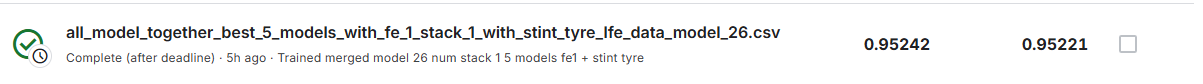